# Dataset 3 — Maximum-Quality Retinal Vessel Segmentation


> **Dataset-3 test-layout fix:** vessel labels for training are read from `training/1st_manual`.
> A generic `mask` folder is treated as the retinal FOV/ROI mask. If the test branch contains
> only `images` + `mask` and no manual vessel annotations, inference still runs normally,
> while Dice/IoU are intentionally skipped because vessel ground truth is absent.

## DenseNet121 Attention U-Net + scSE + Deep Supervision

**Task:** binary retinal blood-vessel segmentation.

This notebook is designed as the vessel-segmentation branch of the same retinal pipeline used for the IDRiD lesion model. It deliberately prioritizes **segmentation quality over training speed**.

### Quality-first strategy

- Keeps any **official training/test split** intact.
- Auto-detects common retinal-vessel layouts, including DRIVE-style:
  - `training/images`
  - `training/1st_manual`
  - `training/mask`
  - corresponding `test/...`
- Uses **native-resolution 512×512 patches** rather than shrinking the complete fundus image.
- Vessel-aware positive patch sampling so thin vessels are not overwhelmed by background.
- Optional field-of-view (FOV) masks; if none are supplied, a conservative FOV is inferred from the image.
- **ImageNet-pretrained DenseNet121** encoder.
- **Attention U-Net + scSE + deep supervision** decoder, consistent with the lesion branch.
- BCE + Dice + Focal-Tversky + soft-clDice topology loss.
- Strong but geometry-consistent augmentation.
- AdamW, differential learning rates, AMP, gradient accumulation, clipping, EMA.
- **5-fold cross-validation on the official training set** to:
  - reduce dependence on one tiny validation split,
  - obtain an out-of-fold threshold,
  - estimate the appropriate final training duration.
- Final **single deployment model** is refit on all official training images.
- Fold checkpoints are retained for an optional maximum-accuracy ensemble.
- Official test images are not used for threshold selection or model tuning.
- Native-resolution overlapping-tile inference + **4-way flip TTA**.

### Main final output

`/kaggle/working/vessel_densenet121_attention_unet_final_bundle.pth`

The bundle stores the final single-model weights, OOF-derived threshold, normalization, patch/inference settings, and architecture metadata.


In [1]:
# ============================================================
# 1. Imports and reproducibility
# ============================================================
import os
import re
import gc
import json
import math
import random
import warnings
from copy import deepcopy
from pathlib import Path
from collections import defaultdict

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision.models import densenet121, DenseNet121_Weights

from sklearn.model_selection import KFold
from sklearn.metrics import roc_auc_score, average_precision_score

warnings.filterwarnings("ignore")

SEED = 42

def seed_everything(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

seed_everything()

if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
AMP = torch.cuda.is_available()

print("PyTorch:", torch.__version__)
print("Device :", DEVICE)
if torch.cuda.is_available():
    print("GPU    :", torch.cuda.get_device_name(0))


PyTorch: 2.10.0+cu128
Device : cuda
GPU    : Tesla T4


In [2]:
# ============================================================
# 2. Maximum-quality configuration
# ============================================================
PATCH_SIZE = 512
INFER_STRIDE = 384

BATCH_SIZE = 2
ACCUMULATION_STEPS = 2
NUM_WORKERS = 2

PATCHES_PER_IMAGE = 24
POSITIVE_CENTER_PROB = 0.70

N_FOLDS = 5
MAX_EPOCHS_PER_FOLD = 120
FREEZE_ENCODER_EPOCHS = 3
EARLY_STOPPING_PATIENCE = 20

ENCODER_LR = 4e-5
DECODER_LR = 2e-4
WEIGHT_DECAY = 2e-4
GRAD_CLIP_NORM = 1.0

LR_PATIENCE = 5
LR_FACTOR = 0.5
MIN_LR = 5e-7

EMA_DECAY = 0.999
PRETRAINED = True

LOSS_W_BCE = 0.25
LOSS_W_DICE = 0.30
LOSS_W_TVERSKY = 0.25
LOSS_W_CLDICE = 0.20

TVERSKY_ALPHA = 0.30
TVERSKY_BETA = 0.70
TVERSKY_GAMMA = 0.75
CLDICE_ITERS = 6

DEEP_SUPERVISION_WEIGHT = 0.30

TRAIN_THRESHOLD_GRID = np.arange(0.10, 0.91, 0.05)
FINAL_THRESHOLD_GRID = np.arange(0.05, 0.951, 0.01)

FINAL_EPOCH_MULTIPLIER = 1.05
MIN_FINAL_EPOCHS = 30

USE_TTA_FOR_OOF = True
USE_TTA_FOR_TEST = True
EVALUATE_CV_ENSEMBLE = True

IMAGENET_MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
IMAGENET_STD  = np.array([0.229, 0.224, 0.225], dtype=np.float32)

OUTPUT_DIR = Path("/kaggle/working") if Path("/kaggle/working").exists() else Path("./vessel_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

FOLD_DIR = OUTPUT_DIR / "vessel_cv_folds"
FOLD_DIR.mkdir(parents=True, exist_ok=True)

FINAL_SINGLE_CKPT = OUTPUT_DIR / "vessel_densenet121_attention_unet_final.pth"
FINAL_BUNDLE = OUTPUT_DIR / "vessel_densenet121_attention_unet_final_bundle.pth"
OOF_THRESHOLD_JSON = OUTPUT_DIR / "vessel_oof_threshold.json"
CV_SUMMARY_CSV = OUTPUT_DIR / "vessel_cv_summary.csv"
FINAL_HISTORY_CSV = OUTPUT_DIR / "vessel_final_training_history.csv"
TEST_METRICS_CSV = OUTPUT_DIR / "vessel_test_metrics.csv"
ENSEMBLE_TEST_METRICS_CSV = OUTPUT_DIR / "vessel_cv_ensemble_test_metrics.csv"

CONFIG = {
    "seed": SEED,
    "task": "binary_retinal_vessel_segmentation",
    "patch_size": PATCH_SIZE,
    "infer_stride": INFER_STRIDE,
    "batch_size": BATCH_SIZE,
    "accumulation_steps": ACCUMULATION_STEPS,
    "patches_per_image": PATCHES_PER_IMAGE,
    "positive_center_probability": POSITIVE_CENTER_PROB,
    "n_folds": N_FOLDS,
    "max_epochs_per_fold": MAX_EPOCHS_PER_FOLD,
    "freeze_encoder_epochs": FREEZE_ENCODER_EPOCHS,
    "encoder_lr": ENCODER_LR,
    "decoder_lr": DECODER_LR,
    "weight_decay": WEIGHT_DECAY,
    "ema_decay": EMA_DECAY,
    "deep_supervision_weight": DEEP_SUPERVISION_WEIGHT,
    "tta": "identity+hflip+vflip+hvflip",
}
print(json.dumps(CONFIG, indent=2))


{
  "seed": 42,
  "task": "binary_retinal_vessel_segmentation",
  "patch_size": 512,
  "infer_stride": 384,
  "batch_size": 2,
  "accumulation_steps": 2,
  "patches_per_image": 24,
  "positive_center_probability": 0.7,
  "n_folds": 5,
  "max_epochs_per_fold": 120,
  "freeze_encoder_epochs": 3,
  "encoder_lr": 4e-05,
  "decoder_lr": 0.0002,
  "weight_decay": 0.0002,
  "ema_decay": 0.999,
  "deep_supervision_weight": 0.3,
  "tta": "identity+hflip+vflip+hvflip"
}


## 3. Strict dataset audit and image/mask pairing

The loader does **not** assume that Kaggle's display name is the physical `/kaggle/input/...` folder name.

It looks for an official train/test layout and distinguishes:

- original fundus image,
- vessel ground-truth mask,
- optional retinal field-of-view mask.

For DRIVE-style data, vessel masks such as `21_manual1.gif` are separated from FOV masks such as `21_training_mask.gif`.

If the attached dataset is not paired safely, the notebook stops rather than silently training on incorrect files.


In [3]:
# ============================================================
# 3. Auto-detect and audit the vessel dataset
# ============================================================
IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".gif", ".ppm"}

def path_text(p):
    return str(p).lower().replace("\\", "/")

def extract_case_id(path):
    # Examples:
    #   21_training.tif -> 21
    #   21_manual1.gif -> 21
    #   21_training_mask.gif -> 21
    stem = path.stem.lower()
    nums = re.findall(r"\d+", stem)
    if nums:
        return str(int(nums[0]))
    stem = re.sub(r"(training|train|testing|test|manual\d*|mask|vessel|label|groundtruth|ground_truth|gt)", "", stem)
    stem = re.sub(r"[^a-z0-9]+", "_", stem).strip("_")
    return stem

def split_from_path(path):
    p = path_text(path)
    parts = [x.lower() for x in path.parts]
    if any(x in {"training", "train", "training set", "train_set"} for x in parts):
        return "train"
    if any(x in {"testing", "test", "testing set", "test_set"} for x in parts):
        return "test"
    if "/training/" in p or "/train/" in p or "training set" in p:
        return "train"
    if "/testing/" in p or "/test/" in p or "testing set" in p:
        return "test"
    return None

def looks_like_original_image(path):
    p = path_text(path)
    parent = path.parent.name.lower()

    if "image" in parent:
        if any(k in p for k in ["manual", "groundtruth", "ground truth", "/label", "/mask", "vessel mask"]):
            return False
        return True

    bad = ["manual", "groundtruth", "ground truth", "/label", "annotation", "_mask", "vessel_mask"]
    return not any(k in p for k in bad)

def vessel_mask_score(path):
    p = path_text(path)
    stem = path.stem.lower()
    score = 0

    if "manual" in p:
        score += 100
    if "1st_manual" in p or "manual1" in stem:
        score += 40
    if "vessel" in p:
        score += 80
    if "groundtruth" in p or "ground truth" in p:
        score += 70
    if "/label" in p or "annotation" in p or "/gt/" in p:
        score += 60

    if "_mask" in stem and "vessel" not in p:
        score -= 40
    if path.parent.name.lower() in {"mask", "masks"} and "vessel" not in p:
        score -= 30

    return score

def fov_mask_score(path):
    p = path_text(path)
    stem = path.stem.lower()
    score = 0
    if "_mask" in stem:
        score += 70
    if path.parent.name.lower() in {"mask", "masks"}:
        score += 60
    if "fov" in p or "field" in p:
        score += 90
    if "manual" in p or "vessel" in p or "groundtruth" in p or "label" in p:
        score -= 100
    return score

KAGGLE_INPUT = Path("/kaggle/input")
if not KAGGLE_INPUT.exists():
    raise RuntimeError("/kaggle/input was not found. Run this notebook on Kaggle.")

all_files = [
    p for p in KAGGLE_INPUT.rglob("*")
    if p.is_file() and p.suffix.lower() in IMAGE_EXTS
]

if not all_files:
    raise RuntimeError("No supported image files were found under /kaggle/input.")

split_files = {"train": [], "test": []}
for p in all_files:
    sp = split_from_path(p)
    if sp in split_files:
        split_files[sp].append(p)

if not split_files["train"]:
    raise RuntimeError(
        "No official training folder could be identified. "
        "Expected a path containing training/train."
    )
if not split_files["test"]:
    raise RuntimeError(
        "No official testing folder could be identified. "
        "Expected a path containing testing/test."
    )

def build_records(files, split):
    originals = [p for p in files if looks_like_original_image(p)]

    image_dir_originals = [p for p in originals if "image" in p.parent.name.lower()]
    if image_dir_originals:
        originals = image_dir_originals

    grouped = defaultdict(list)
    for p in files:
        grouped[extract_case_id(p)].append(p)

    records = []
    used_ids = set()

    for img in sorted(originals):
        case_id = extract_case_id(img)
        if case_id in used_ids:
            continue

        candidates = [p for p in grouped[case_id] if p != img]

        vessel_candidates = sorted(
            [(vessel_mask_score(p), p) for p in candidates],
            key=lambda x: x[0],
            reverse=True,
        )
        fov_candidates = sorted(
            [(fov_mask_score(p), p) for p in candidates],
            key=lambda x: x[0],
            reverse=True,
        )

        vessel_path = vessel_candidates[0][1] if vessel_candidates and vessel_candidates[0][0] > 0 else None
        fov_path = fov_candidates[0][1] if fov_candidates and fov_candidates[0][0] > 0 else None

        if vessel_path is not None and fov_path == vessel_path:
            fov_path = None

        # Training MUST have a true vessel annotation. Test images may be
        # unlabeled for vessels; in that case they are retained for inference.
        if split == "train" and vessel_path is None:
            continue

        records.append({
            "id": case_id,
            "split": split,
            "image": img,
            "vessel_mask": vessel_path,
            "fov_mask": fov_path,
            "has_vessel_gt": vessel_path is not None,
        })
        used_ids.add(case_id)

    return records

train_records = build_records(split_files["train"], "train")
test_records = build_records(split_files["test"], "test")

print("Paired vessel-segmentation records:")
print("  Train:", len(train_records), "(vessel GT required)")
print("  Test :", len(test_records))
print("  Test vessel GT available:", sum(r.get("has_vessel_gt", False) for r in test_records), "/", len(test_records))

if len(train_records) < 5:
    raise RuntimeError(
        f"Only {len(train_records)} training image/mask pairs were identified. "
        "The dataset structure should be inspected before training."
    )
if len(test_records) < 1:
    raise RuntimeError("No official test images were identified. Check the test/test/images folder.")

train_ids = {r["id"] for r in train_records}
test_ids = {r["id"] for r in test_records}
assert train_ids.isdisjoint(test_ids), "STOP: train/test case-ID leakage detected."

if len(train_records) == 20 and len(test_records) == 20:
    print("DRIVE-style 20/20 official split detected.")
else:
    print("Non-20/20 vessel dataset detected; using its actual official split.")

TEST_HAS_GT = all(r.get("has_vessel_gt", False) for r in test_records)
if TEST_HAS_GT:
    print("Test vessel ground truth: AVAILABLE — final test metrics will run.")
else:
    print("Test vessel ground truth: NOT AVAILABLE for all test images.")
    print("The test mask folder is treated as FOV/ROI only; inference will run, but Dice/IoU will be skipped.")

audit_df = pd.DataFrame([{
    "id": r["id"],
    "split": r["split"],
    "image": str(r["image"]),
    "vessel_mask": str(r["vessel_mask"]) if r["vessel_mask"] is not None else "UNLABELED_TEST",
    "fov_mask": str(r["fov_mask"]) if r["fov_mask"] is not None else "INFERRED",
    "has_vessel_gt": r.get("has_vessel_gt", r["vessel_mask"] is not None),
} for r in train_records + test_records])

print("Official split leakage check: PASSED")
display(audit_df.head(20))


Paired vessel-segmentation records:
  Train: 20 (vessel GT required)
  Test : 20
  Test vessel GT available: 0 / 20
DRIVE-style 20/20 official split detected.
Test vessel ground truth: NOT AVAILABLE for all test images.
The test mask folder is treated as FOV/ROI only; inference will run, but Dice/IoU will be skipped.
Official split leakage check: PASSED


,id,split,image,vessel_mask,fov_mask,has_vessel_gt
0,21,train,/kaggle/input/datasets/yashraneja/dataset-3-ve...,/kaggle/input/datasets/yashraneja/dataset-3-ve...,/kaggle/input/datasets/yashraneja/dataset-3-ve...,True
1,22,train,/kaggle/input/datasets/yashraneja/dataset-3-ve...,/kaggle/input/datasets/yashraneja/dataset-3-ve...,/kaggle/input/datasets/yashraneja/dataset-3-ve...,True
2,23,train,/kaggle/input/datasets/yashraneja/dataset-3-ve...,/kaggle/input/datasets/yashraneja/dataset-3-ve...,/kaggle/input/datasets/yashraneja/dataset-3-ve...,True
3,24,train,/kaggle/input/datasets/yashraneja/dataset-3-ve...,/kaggle/input/datasets/yashraneja/dataset-3-ve...,/kaggle/input/datasets/yashraneja/dataset-3-ve...,True
4,25,train,/kaggle/input/datasets/yashraneja/dataset-3-ve...,/kaggle/input/datasets/yashraneja/dataset-3-ve...,/kaggle/input/datasets/yashraneja/dataset-3-ve...,True
5,26,train,/kaggle/input/datasets/yashraneja/dataset-3-ve...,/kaggle/input/datasets/yashraneja/dataset-3-ve...,/kaggle/input/datasets/yashraneja/dataset-3-ve...,True
6,27,train,/kaggle/input/datasets/yashraneja/dataset-3-ve...,/kaggle/input/datasets/yashraneja/dataset-3-ve...,/kaggle/input/datasets/yashraneja/dataset-3-ve...,True
7,28,train,/kaggle/input/datasets/yashraneja/dataset-3-ve...,/kaggle/input/datasets/yashraneja/dataset-3-ve...,/kaggle/input/datasets/yashraneja/dataset-3-ve...,True
8,29,train,/kaggle/input/datasets/yashraneja/dataset-3-ve...,/kaggle/input/datasets/yashraneja/dataset-3-ve...,/kaggle/input/datasets/yashraneja/dataset-3-ve...,True
9,30,train,/kaggle/input/datasets/yashraneja/dataset-3-ve...,/kaggle/input/datasets/yashraneja/dataset-3-ve...,/kaggle/input/datasets/yashraneja/dataset-3-ve...,True


In [4]:
# ============================================================
# 4. Image reading, FOV handling and dataset integrity checks
# ============================================================
def read_rgb(path):
    bgr = cv2.imread(str(path), cv2.IMREAD_COLOR)
    if bgr is None:
        raise RuntimeError(f"Could not read image: {path}")
    return cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)

def read_binary(path):
    if path is None:
        return None
    m = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    if m is None:
        from PIL import Image
        m = np.array(Image.open(path).convert("L"))
    return (m > 0).astype(np.uint8)

def infer_fov(rgb):
    gray = cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY)
    fov = (gray > 8).astype(np.uint8)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (15, 15))
    fov = cv2.morphologyEx(fov, cv2.MORPH_CLOSE, kernel)
    return fov

def load_record_arrays(record):
    rgb = read_rgb(record["image"])
    vessel = read_binary(record["vessel_mask"]) if record.get("vessel_mask") is not None else None
    fov = read_binary(record["fov_mask"]) if record["fov_mask"] is not None else infer_fov(rgb)

    if vessel is not None and vessel.shape != rgb.shape[:2]:
        vessel = cv2.resize(vessel, (rgb.shape[1], rgb.shape[0]), interpolation=cv2.INTER_NEAREST)
    if fov.shape != rgb.shape[:2]:
        fov = cv2.resize(fov, (rgb.shape[1], rgb.shape[0]), interpolation=cv2.INTER_NEAREST)

    fov = (fov > 0).astype(np.uint8)
    if vessel is not None:
        vessel = (vessel > 0).astype(np.uint8)
        vessel = vessel * fov
    return rgb, vessel, fov

def audit_records(records, name, require_vessel_gt=False):
    rows = []
    for r in records:
        rgb, vessel, fov = load_record_arrays(r)
        fov_pixels = int(fov.sum())
        if vessel is None:
            vessel_pixels = np.nan
            vessel_fraction = np.nan
        else:
            vessel_pixels = int((vessel * fov).sum())
            vessel_fraction = vessel_pixels / max(fov_pixels, 1)
        rows.append({
            "id": r["id"],
            "H": rgb.shape[0],
            "W": rgb.shape[1],
            "fov_pixels": fov_pixels,
            "vessel_pixels": vessel_pixels,
            "vessel_fraction_in_fov": vessel_fraction,
            "has_vessel_gt": vessel is not None,
        })

    df = pd.DataFrame(rows)
    if require_vessel_gt:
        if not df["has_vessel_gt"].all():
            bad = df.loc[~df["has_vessel_gt"], "id"].tolist()
            raise RuntimeError(f"{name}: missing vessel GT for cases {bad}")
        if (df["vessel_pixels"] <= 0).any():
            bad = df.loc[df["vessel_pixels"] <= 0, "id"].tolist()
            raise RuntimeError(f"{name}: empty vessel masks detected for cases {bad}")

    print(f"{name}: {len(df)} valid images")
    labeled = df[df["has_vessel_gt"]]
    if len(labeled):
        print(
            "  vessel fraction in FOV:",
            f"mean={labeled['vessel_fraction_in_fov'].mean():.4f}, "
            f"min={labeled['vessel_fraction_in_fov'].min():.4f}, "
            f"max={labeled['vessel_fraction_in_fov'].max():.4f}"
        )
    else:
        print("  no vessel GT present; this is an inference-only test set.")
    return df

train_audit = audit_records(train_records, "TRAIN", require_vessel_gt=True)
test_audit = audit_records(test_records, "TEST", require_vessel_gt=False)

print("Dataset integrity audit: PASSED")
display(train_audit.head())


TRAIN: 20 valid images
  vessel fraction in FOV: mean=0.1254, min=0.0874, max=0.1678
TEST: 20 valid images
  no vessel GT present; this is an inference-only test set.
Dataset integrity audit: PASSED


,id,H,W,fov_pixels,vessel_pixels,vessel_fraction_in_fov,has_vessel_gt
0,21,584,565,225600,24650,0.109264,True
1,22,584,565,227686,29800,0.130882,True
2,23,584,565,228187,21714,0.095159,True
3,24,584,565,227726,38215,0.167811,True
4,25,584,565,227362,31664,0.139267,True


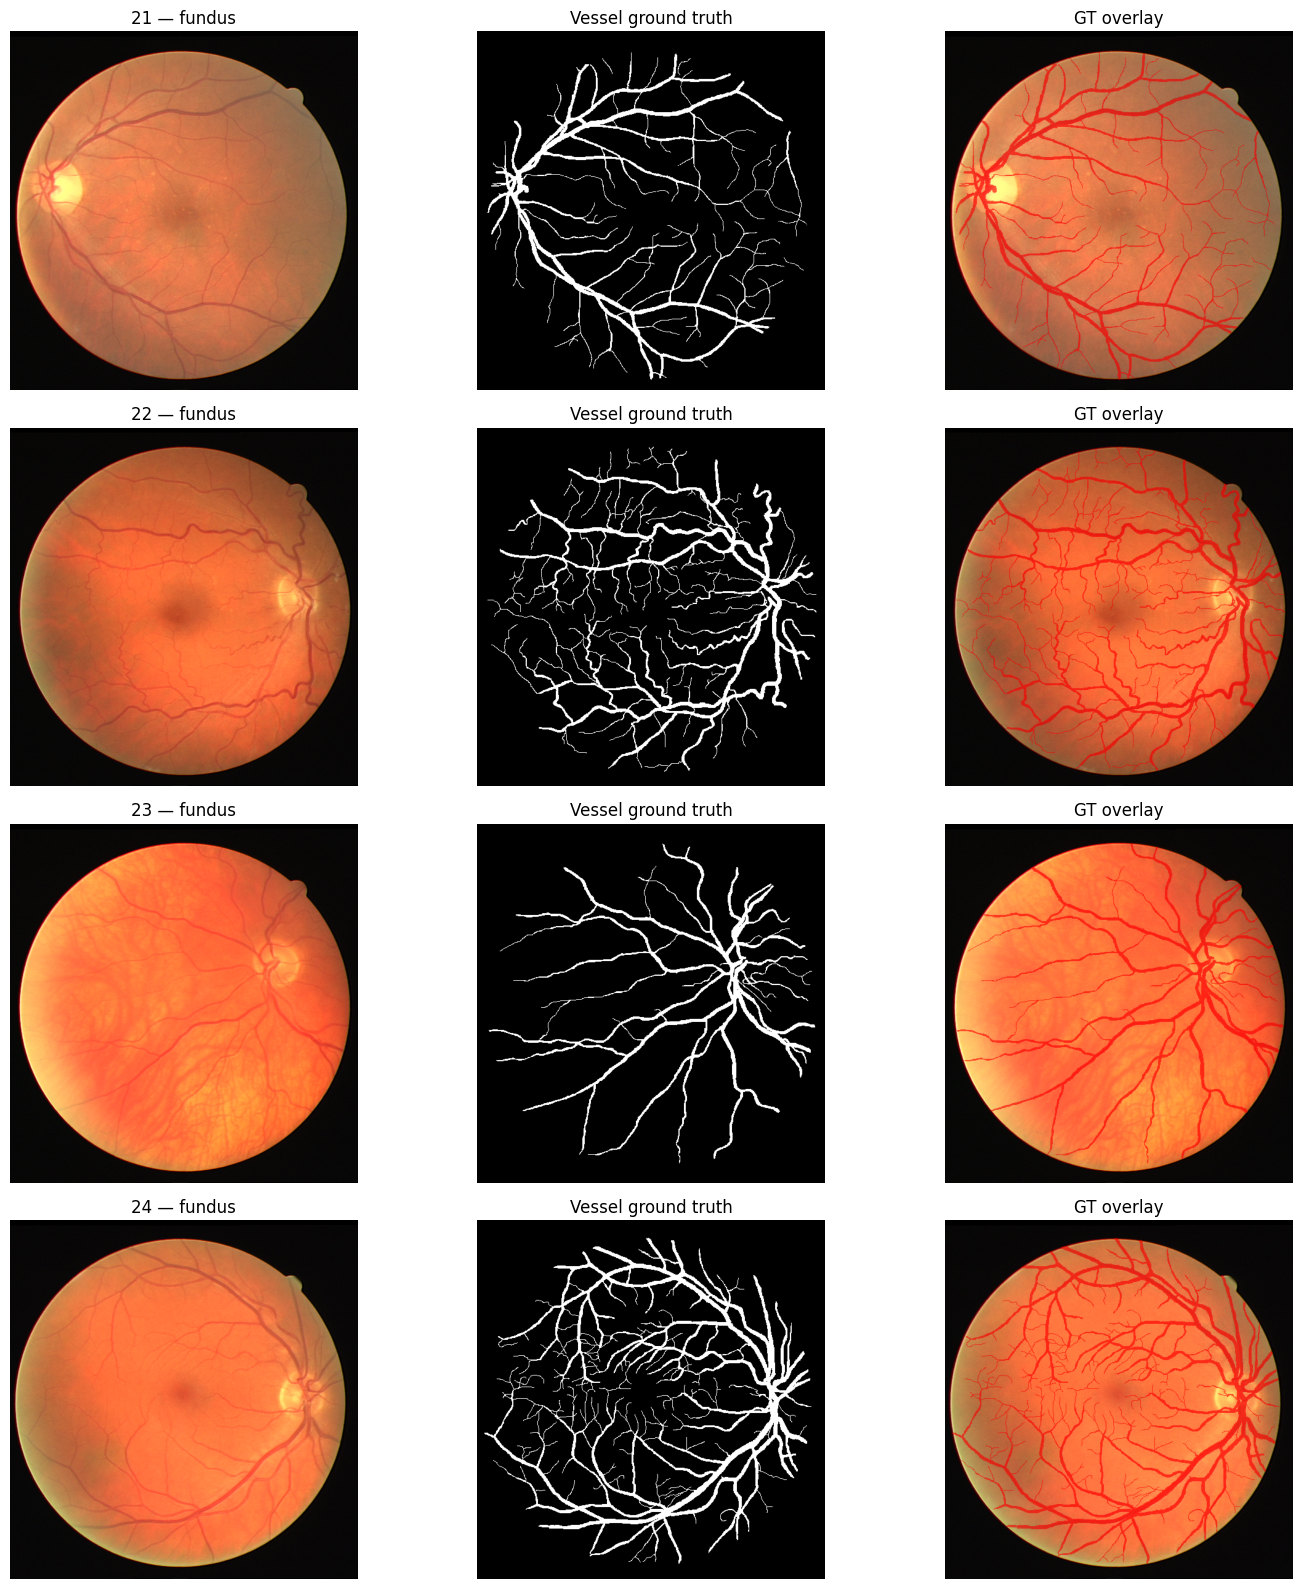

In [5]:
# ============================================================
# 5. Visualization sanity check
# ============================================================
def overlay_vessels(rgb, mask, alpha=0.6):
    out = rgb.astype(np.float32).copy()
    red = np.zeros_like(out)
    red[..., 0] = 255
    region = mask.astype(bool)
    out[region] = (1 - alpha) * out[region] + alpha * red[region]
    return np.clip(out, 0, 255).astype(np.uint8)

n_show = min(4, len(train_records))
fig, axes = plt.subplots(n_show, 3, figsize=(15, 4*n_show))
if n_show == 1:
    axes = np.expand_dims(axes, 0)

for row, r in enumerate(train_records[:n_show]):
    rgb, vessel, fov = load_record_arrays(r)
    axes[row, 0].imshow(rgb)
    axes[row, 0].set_title(f"{r['id']} — fundus")
    axes[row, 1].imshow(vessel, cmap="gray")
    axes[row, 1].set_title("Vessel ground truth")
    axes[row, 2].imshow(overlay_vessels(rgb, vessel))
    axes[row, 2].set_title("GT overlay")
    for col in range(3):
        axes[row, col].axis("off")

plt.tight_layout()
plt.show()


## 6. Native-resolution vessel patches

The model is **not** trained by shrinking the complete fundus image to 224/256 pixels.

Each patch is sampled directly from the original image:

- ~70% of patches are centered around a true vessel pixel.
- the remaining patches are sampled within the retinal FOV.
- geometry is applied identically to the image, vessel mask and FOV mask.
- photometric augmentation is applied only to the RGB image.

This helps preserve thin vessels and capillary branches.


In [6]:
# ============================================================
# 6. Native-resolution patch dataset + augmentation
# ============================================================
def pad_to_minimum(arr, min_h, min_w, is_mask=False):
    h, w = arr.shape[:2]
    pad_h = max(0, min_h - h)
    pad_w = max(0, min_w - w)
    if pad_h == 0 and pad_w == 0:
        return arr

    if arr.ndim == 3:
        return cv2.copyMakeBorder(arr, 0, pad_h, 0, pad_w, cv2.BORDER_REFLECT_101)
    border = cv2.BORDER_CONSTANT if is_mask else cv2.BORDER_REFLECT_101
    return cv2.copyMakeBorder(arr, 0, pad_h, 0, pad_w, border, value=0)

def extract_patch(arr, cy, cx, size):
    h, w = arr.shape[:2]
    y0 = int(np.clip(cy - size // 2, 0, h - size))
    x0 = int(np.clip(cx - size // 2, 0, w - size))
    return arr[y0:y0+size, x0:x0+size]

def synchronized_geometric_aug(rgb, vessel, fov, rng):
    if rng.random() < 0.5:
        rgb = np.flip(rgb, axis=1).copy()
        vessel = np.flip(vessel, axis=1).copy()
        fov = np.flip(fov, axis=1).copy()

    if rng.random() < 0.5:
        rgb = np.flip(rgb, axis=0).copy()
        vessel = np.flip(vessel, axis=0).copy()
        fov = np.flip(fov, axis=0).copy()

    k = int(rng.integers(0, 4))
    if k:
        rgb = np.rot90(rgb, k, axes=(0, 1)).copy()
        vessel = np.rot90(vessel, k, axes=(0, 1)).copy()
        fov = np.rot90(fov, k, axes=(0, 1)).copy()

    return rgb, vessel, fov

def photometric_aug(rgb, rng):
    x = rgb.astype(np.float32) / 255.0

    if rng.random() < 0.70:
        contrast = float(rng.uniform(0.85, 1.15))
        brightness = float(rng.uniform(-0.08, 0.08))
        x = x * contrast + brightness

    if rng.random() < 0.45:
        gamma = float(rng.uniform(0.80, 1.25))
        x = np.power(np.clip(x, 0, 1), gamma)

    if rng.random() < 0.35:
        gains = rng.uniform(0.92, 1.08, size=(1, 1, 3)).astype(np.float32)
        x = x * gains

    if rng.random() < 0.25:
        sigma = float(rng.uniform(0.0, 0.015))
        x = x + rng.normal(0, sigma, size=x.shape).astype(np.float32)

    if rng.random() < 0.20:
        temp = np.clip(x * 255, 0, 255).astype(np.uint8)
        lab = cv2.cvtColor(temp, cv2.COLOR_RGB2LAB)
        l, a, b = cv2.split(lab)
        clahe = cv2.createCLAHE(clipLimit=1.5, tileGridSize=(8, 8))
        l = clahe.apply(l)
        temp = cv2.cvtColor(cv2.merge([l, a, b]), cv2.COLOR_LAB2RGB)
        x = temp.astype(np.float32) / 255.0

    return np.clip(x, 0, 1)

def normalize_rgb(rgb01):
    x = (rgb01.astype(np.float32) - IMAGENET_MEAN) / IMAGENET_STD
    return x.transpose(2, 0, 1).astype(np.float32)

class VesselPatchDataset(Dataset):
    def __init__(self, records, patches_per_image=PATCHES_PER_IMAGE, augment=True, seed=SEED):
        self.records = records
        self.patches_per_image = patches_per_image
        self.augment = augment
        self.seed = seed
        self.cache = {}
        for i, r in enumerate(records):
            self.cache[i] = load_record_arrays(r)

    def __len__(self):
        return len(self.records) * self.patches_per_image

    def __getitem__(self, idx):
        rec_idx = idx % len(self.records)
        rng = np.random.default_rng(np.random.randint(0, 2**31 - 1))

        rgb, vessel, fov = self.cache[rec_idx]
        rgb = pad_to_minimum(rgb, PATCH_SIZE, PATCH_SIZE)
        vessel = pad_to_minimum(vessel, PATCH_SIZE, PATCH_SIZE, is_mask=True)
        fov = pad_to_minimum(fov, PATCH_SIZE, PATCH_SIZE, is_mask=True)

        if rng.random() < POSITIVE_CENTER_PROB and vessel.any():
            ys, xs = np.where(vessel > 0)
        else:
            ys, xs = np.where(fov > 0)

        if len(ys) == 0:
            cy, cx = rgb.shape[0] // 2, rgb.shape[1] // 2
        else:
            j = int(rng.integers(0, len(ys)))
            cy, cx = int(ys[j]), int(xs[j])

        rgb_p = extract_patch(rgb, cy, cx, PATCH_SIZE)
        ves_p = extract_patch(vessel, cy, cx, PATCH_SIZE)
        fov_p = extract_patch(fov, cy, cx, PATCH_SIZE)

        if self.augment:
            rgb_p, ves_p, fov_p = synchronized_geometric_aug(rgb_p, ves_p, fov_p, rng)
            rgb01 = photometric_aug(rgb_p, rng)
        else:
            rgb01 = rgb_p.astype(np.float32) / 255.0

        x = torch.from_numpy(normalize_rgb(rgb01))
        y = torch.from_numpy(ves_p[None].astype(np.float32))
        valid = torch.from_numpy(fov_p[None].astype(np.float32))

        return {"image": x, "mask": y, "valid": valid, "id": self.records[rec_idx]["id"]}


In [7]:
# ============================================================
# 7. DenseNet121 Attention U-Net + scSE + deep supervision
# ============================================================
def make_group_norm(channels):
    for groups in (16, 8, 4, 2, 1):
        if channels % groups == 0:
            return nn.GroupNorm(groups, channels)
    return nn.GroupNorm(1, channels)

class SCSE(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        hidden = max(channels // reduction, 8)
        self.cse = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(channels, hidden, 1),
            nn.ReLU(inplace=True),
            nn.Conv2d(hidden, channels, 1),
            nn.Sigmoid(),
        )
        self.sse = nn.Sequential(
            nn.Conv2d(channels, 1, 1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        return x * self.cse(x) + x * self.sse(x)

class ConvGNAct(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.0):
        super().__init__()
        layers = [
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            make_group_norm(out_ch),
            nn.SiLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            make_group_norm(out_ch),
            nn.SiLU(inplace=True),
        ]
        if dropout > 0:
            layers.append(nn.Dropout2d(dropout))
        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)

class UpAttentionBlock(nn.Module):
    def __init__(self, in_ch, skip_ch, out_ch, dropout=0.0):
        super().__init__()
        self.conv = ConvGNAct(in_ch + skip_ch, out_ch, dropout=dropout)
        self.attn = SCSE(out_ch)

    def forward(self, x, skip):
        x = F.interpolate(x, size=skip.shape[-2:], mode="bilinear", align_corners=False)
        x = torch.cat([x, skip], dim=1)
        return self.attn(self.conv(x))

class DenseNet121AttentionUNet(nn.Module):
    def __init__(self, num_classes=1, pretrained=True):
        super().__init__()
        weights = DenseNet121_Weights.DEFAULT if pretrained else None
        try:
            backbone = densenet121(weights=weights, memory_efficient=True)
            if pretrained:
                print("Loaded ImageNet-pretrained memory-efficient DenseNet121 encoder.")
        except Exception as e:
            print("WARNING: pretrained weights could not be loaded:", e)
            print("Falling back to randomly initialized DenseNet121.")
            backbone = densenet121(weights=None, memory_efficient=True)

        f = backbone.features
        self.enc0 = nn.Sequential(f.conv0, f.norm0, f.relu0)
        self.pool0 = f.pool0
        self.enc1 = f.denseblock1
        self.tr1 = f.transition1
        self.enc2 = f.denseblock2
        self.tr2 = f.transition2
        self.enc3 = f.denseblock3
        self.tr3 = f.transition3
        self.enc4 = f.denseblock4
        self.norm5 = f.norm5

        self.up3 = UpAttentionBlock(1024, 1024, 512, dropout=0.15)
        self.up2 = UpAttentionBlock(512, 512, 256, dropout=0.10)
        self.up1 = UpAttentionBlock(256, 256, 128, dropout=0.08)
        self.up0 = UpAttentionBlock(128, 64, 64, dropout=0.05)

        self.final_conv = ConvGNAct(64, 32)
        self.head = nn.Conv2d(32, num_classes, 1)

        self.aux2 = nn.Conv2d(256, num_classes, 1)
        self.aux1 = nn.Conv2d(128, num_classes, 1)
        self.aux0 = nn.Conv2d(64, num_classes, 1)

    def forward(self, x, return_aux=False):
        input_hw = x.shape[-2:]

        s0 = self.enc0(x)
        x = self.pool0(s0)

        s1 = self.enc1(x)
        x = self.tr1(s1)

        s2 = self.enc2(x)
        x = self.tr2(s2)

        s3 = self.enc3(x)
        x = self.tr3(s3)

        x = F.silu(self.norm5(self.enc4(x)), inplace=True)

        x3 = self.up3(x, s3)
        x2 = self.up2(x3, s2)
        x1 = self.up1(x2, s1)
        x0 = self.up0(x1, s0)

        main = F.interpolate(x0, size=input_hw, mode="bilinear", align_corners=False)
        main = self.head(self.final_conv(main))

        if not return_aux:
            return main

        aux = [
            F.interpolate(self.aux2(x2), size=input_hw, mode="bilinear", align_corners=False),
            F.interpolate(self.aux1(x1), size=input_hw, mode="bilinear", align_corners=False),
            F.interpolate(self.aux0(x0), size=input_hw, mode="bilinear", align_corners=False),
        ]
        return main, aux

    def encoder_parameters(self):
        modules = [
            self.enc0, self.pool0, self.enc1, self.tr1, self.enc2, self.tr2,
            self.enc3, self.tr3, self.enc4, self.norm5
        ]
        for module in modules:
            yield from module.parameters()

    def decoder_parameters(self):
        modules = [
            self.up3, self.up2, self.up1, self.up0,
            self.final_conv, self.head, self.aux2, self.aux1, self.aux0
        ]
        for module in modules:
            yield from module.parameters()

    def set_encoder_trainable(self, trainable=True):
        for p in self.encoder_parameters():
            p.requires_grad = trainable

    def freeze_encoder_batchnorm(self):
        modules = [
            self.enc0, self.enc1, self.tr1, self.enc2, self.tr2,
            self.enc3, self.tr3, self.enc4, self.norm5
        ]
        for module in modules:
            for m in module.modules():
                if isinstance(m, nn.BatchNorm2d):
                    m.eval()
                    for p in m.parameters():
                        p.requires_grad = False

_tmp_model = DenseNet121AttentionUNet(num_classes=1, pretrained=PRETRAINED).to(DEVICE)
_tmp_model.set_encoder_trainable(False)
_tmp_model.freeze_encoder_batchnorm()

with torch.no_grad():
    dummy = torch.randn(1, 3, 128, 128, device=DEVICE)
    main, aux = _tmp_model(dummy, return_aux=True)

print("Main output:", tuple(main.shape))
print("Aux outputs :", [tuple(a.shape) for a in aux])

del _tmp_model, dummy, main, aux
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()


Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 172MB/s]


Loaded ImageNet-pretrained memory-efficient DenseNet121 encoder.
Main output: (1, 1, 128, 128)
Aux outputs : [(1, 1, 128, 128), (1, 1, 128, 128), (1, 1, 128, 128)]


In [8]:
# ============================================================
# 8. Vessel-specific loss: BCE + Dice + Focal-Tversky + soft-clDice
# ============================================================
def compute_pos_weight(records):
    pos = 0
    neg = 0
    for r in records:
        _, vessel, fov = load_record_arrays(r)
        valid = fov > 0
        p = int(vessel[valid].sum())
        n = int(valid.sum() - p)
        pos += p
        neg += n

    w = neg / max(pos, 1)
    return float(np.clip(w, 1.0, 20.0))

GLOBAL_POS_WEIGHT = compute_pos_weight(train_records)
print(f"Global vessel BCE pos_weight = {GLOBAL_POS_WEIGHT:.3f}")

def masked_mean(x, valid, eps=1e-7):
    return (x * valid).sum() / (valid.sum() + eps)

def soft_dice_loss_from_probs(probs, target, valid, eps=1e-7):
    probs = probs * valid
    target = target * valid
    inter = (probs * target).sum(dim=(1, 2, 3))
    den = probs.sum(dim=(1, 2, 3)) + target.sum(dim=(1, 2, 3))
    dice = (2 * inter + eps) / (den + eps)
    return 1 - dice.mean()

def focal_tversky_loss_from_probs(probs, target, valid, eps=1e-7):
    probs = probs * valid
    target = target * valid

    tp = (probs * target).sum(dim=(1, 2, 3))
    fp = (probs * (1 - target) * valid).sum(dim=(1, 2, 3))
    fn = ((1 - probs) * target * valid).sum(dim=(1, 2, 3))

    tversky = (tp + eps) / (tp + TVERSKY_ALPHA * fp + TVERSKY_BETA * fn + eps)
    return torch.pow(1 - tversky, TVERSKY_GAMMA).mean()

def soft_erode(img):
    p1 = -F.max_pool2d(-img, kernel_size=(3, 1), stride=1, padding=(1, 0))
    p2 = -F.max_pool2d(-img, kernel_size=(1, 3), stride=1, padding=(0, 1))
    return torch.minimum(p1, p2)

def soft_dilate(img):
    return F.max_pool2d(img, kernel_size=3, stride=1, padding=1)

def soft_open(img):
    return soft_dilate(soft_erode(img))

def soft_skeletonize(img, iters=CLDICE_ITERS):
    opened = soft_open(img)
    skel = F.relu(img - opened)
    for _ in range(iters):
        img = soft_erode(img)
        opened = soft_open(img)
        delta = F.relu(img - opened)
        skel = skel + F.relu(delta - skel * delta)
    return skel

def soft_cldice_loss(probs, target, valid, eps=1e-7):
    probs = probs * valid
    target = target * valid

    skel_p = soft_skeletonize(probs)
    skel_t = soft_skeletonize(target)

    tprec = (torch.sum(skel_p * target) + eps) / (torch.sum(skel_p) + eps)
    tsens = (torch.sum(skel_t * probs) + eps) / (torch.sum(skel_t) + eps)

    cldice = (2 * tprec * tsens + eps) / (tprec + tsens + eps)
    return 1 - cldice

class VesselCompositeLoss(nn.Module):
    def __init__(self, pos_weight):
        super().__init__()
        self.register_buffer("pos_weight", torch.tensor([pos_weight], dtype=torch.float32))

    def forward(self, logits, target, valid):
        bce_map = F.binary_cross_entropy_with_logits(
            logits, target,
            pos_weight=self.pos_weight,
            reduction="none",
        )
        bce = masked_mean(bce_map, valid)

        probs = torch.sigmoid(logits)
        dice = soft_dice_loss_from_probs(probs, target, valid)
        tv = focal_tversky_loss_from_probs(probs, target, valid)
        cl = soft_cldice_loss(probs, target, valid)

        return (
            LOSS_W_BCE * bce +
            LOSS_W_DICE * dice +
            LOSS_W_TVERSKY * tv +
            LOSS_W_CLDICE * cl
        )


Global vessel BCE pos_weight = 6.975


In [9]:
# ============================================================
# 9. EMA, tiled native-resolution inference and TTA
# ============================================================
@torch.no_grad()
def update_ema(ema_model, model, decay=EMA_DECAY):
    ema_params = dict(ema_model.named_parameters())
    model_params = dict(model.named_parameters())

    for name, p_ema in ema_params.items():
        p = model_params[name]
        p_ema.mul_(decay).add_(p.detach(), alpha=1 - decay)

    ema_buffers = dict(ema_model.named_buffers())
    model_buffers = dict(model.named_buffers())
    for name, b_ema in ema_buffers.items():
        b = model_buffers[name]
        if torch.is_floating_point(b_ema):
            b_ema.mul_(decay).add_(b.detach(), alpha=1 - decay)
        else:
            b_ema.copy_(b)

def make_blend_window(size):
    h = np.hanning(size).astype(np.float32)
    w = np.outer(h, h)
    w = 0.10 + 0.90 * (w / max(w.max(), 1e-7))
    return w

BLEND_WINDOW = make_blend_window(PATCH_SIZE)

def preprocess_patch_for_model(rgb_patch):
    x = rgb_patch.astype(np.float32) / 255.0
    x = normalize_rgb(x)
    return torch.from_numpy(x).unsqueeze(0)

@torch.no_grad()
def tiled_predict(model, rgb, patch_size=PATCH_SIZE, stride=INFER_STRIDE):
    model.eval()
    h0, w0 = rgb.shape[:2]

    ph = max(h0, patch_size)
    pw = max(w0, patch_size)
    pad_h = ph - h0
    pad_w = pw - w0

    padded = cv2.copyMakeBorder(
        rgb, 0, pad_h, 0, pad_w,
        borderType=cv2.BORDER_REFLECT_101
    )

    h, w = padded.shape[:2]
    ys = list(range(0, max(h - patch_size, 0) + 1, stride))
    xs = list(range(0, max(w - patch_size, 0) + 1, stride))
    if not ys or ys[-1] != h - patch_size:
        ys.append(h - patch_size)
    if not xs or xs[-1] != w - patch_size:
        xs.append(w - patch_size)

    prob_sum = np.zeros((h, w), dtype=np.float32)
    weight_sum = np.zeros((h, w), dtype=np.float32)

    for y in ys:
        for x in xs:
            patch = padded[y:y+patch_size, x:x+patch_size]
            t = preprocess_patch_for_model(patch).to(DEVICE, non_blocking=True)

            with torch.cuda.amp.autocast(enabled=AMP):
                logits = model(t)
                probs = torch.sigmoid(logits)[0, 0].float().cpu().numpy()

            prob_sum[y:y+patch_size, x:x+patch_size] += probs * BLEND_WINDOW
            weight_sum[y:y+patch_size, x:x+patch_size] += BLEND_WINDOW

    pred = prob_sum / np.maximum(weight_sum, 1e-7)
    return pred[:h0, :w0]

def tta_transform(rgb, mode):
    if mode == "id":
        return rgb
    if mode == "h":
        return np.flip(rgb, axis=1).copy()
    if mode == "v":
        return np.flip(rgb, axis=0).copy()
    if mode == "hv":
        return np.flip(np.flip(rgb, axis=0), axis=1).copy()
    raise ValueError(mode)

def tta_inverse(prob, mode):
    if mode == "id":
        return prob
    if mode == "h":
        return np.flip(prob, axis=1).copy()
    if mode == "v":
        return np.flip(prob, axis=0).copy()
    if mode == "hv":
        return np.flip(np.flip(prob, axis=0), axis=1).copy()
    raise ValueError(mode)

@torch.no_grad()
def predict_full_image(model, rgb, tta=True):
    modes = ["id", "h", "v", "hv"] if tta else ["id"]
    preds = []
    for mode in modes:
        transformed = tta_transform(rgb, mode)
        p = tiled_predict(model, transformed)
        preds.append(tta_inverse(p, mode))
    return np.mean(preds, axis=0).astype(np.float32)


In [10]:
# ============================================================
# 10. Metrics and threshold tuning (FOV only)
# ============================================================
def binary_metrics_from_vectors(prob, target, threshold):
    pred = prob >= threshold
    target_b = target > 0.5

    tp = np.logical_and(pred, target_b).sum()
    fp = np.logical_and(pred, ~target_b).sum()
    fn = np.logical_and(~pred, target_b).sum()
    tn = np.logical_and(~pred, ~target_b).sum()

    eps = 1e-9
    dice = (2 * tp + eps) / (2 * tp + fp + fn + eps)
    iou = (tp + eps) / (tp + fp + fn + eps)
    sensitivity = (tp + eps) / (tp + fn + eps)
    specificity = (tn + eps) / (tn + fp + eps)
    precision = (tp + eps) / (tp + fp + eps)
    accuracy = (tp + tn + eps) / (tp + tn + fp + fn + eps)

    return {
        "dice": float(dice),
        "iou": float(iou),
        "sensitivity": float(sensitivity),
        "specificity": float(specificity),
        "precision": float(precision),
        "accuracy": float(accuracy),
    }

def tune_threshold(prob, target, grid):
    best_t = 0.5
    best_dice = -1.0
    for t in grid:
        m = binary_metrics_from_vectors(prob, target, float(t))
        if m["dice"] > best_dice:
            best_dice = m["dice"]
            best_t = float(t)
    return best_t, best_dice

@torch.no_grad()
def evaluate_records(model, records, threshold_grid=TRAIN_THRESHOLD_GRID, tta=False, return_vectors=False):
    probs_all = []
    targets_all = []

    for r in records:
        rgb, vessel, fov = load_record_arrays(r)
        prob = predict_full_image(model, rgb, tta=tta)

        valid = fov > 0
        probs_all.append(prob[valid].astype(np.float32))
        targets_all.append(vessel[valid].astype(np.uint8))

    prob_vec = np.concatenate(probs_all)
    target_vec = np.concatenate(targets_all)

    threshold, _ = tune_threshold(prob_vec, target_vec, threshold_grid)
    metrics = binary_metrics_from_vectors(prob_vec, target_vec, threshold)

    try:
        metrics["roc_auc"] = float(roc_auc_score(target_vec, prob_vec))
    except Exception:
        metrics["roc_auc"] = float("nan")
    try:
        metrics["auprc"] = float(average_precision_score(target_vec, prob_vec))
    except Exception:
        metrics["auprc"] = float("nan")

    metrics["threshold"] = float(threshold)

    if return_vectors:
        return metrics, prob_vec, target_vec
    return metrics


In [11]:
# ============================================================
# 11. Cross-validation fold construction
# ============================================================
if len(train_records) < N_FOLDS:
    raise RuntimeError(
        f"N_FOLDS={N_FOLDS} but only {len(train_records)} training records were found."
    )

kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
indices = np.arange(len(train_records))
fold_splits = list(kf.split(indices))

print(f"{N_FOLDS}-fold cross-validation")
for fold, (tr_idx, va_idx) in enumerate(fold_splits, 1):
    print(f"  Fold {fold}: train={len(tr_idx)} | val={len(va_idx)}")


5-fold cross-validation
  Fold 1: train=16 | val=4
  Fold 2: train=16 | val=4
  Fold 3: train=16 | val=4
  Fold 4: train=16 | val=4
  Fold 5: train=16 | val=4


In [12]:
# ============================================================
# 12. One-fold training function
# ============================================================
def make_optimizer(model):
    return torch.optim.AdamW(
        [
            {"params": list(model.encoder_parameters()), "lr": ENCODER_LR},
            {"params": list(model.decoder_parameters()), "lr": DECODER_LR},
        ],
        weight_decay=WEIGHT_DECAY,
    )

def make_train_loader(records, seed_offset=0):
    ds = VesselPatchDataset(
        records,
        patches_per_image=PATCHES_PER_IMAGE,
        augment=True,
        seed=SEED + seed_offset,
    )
    g = torch.Generator()
    g.manual_seed(SEED + seed_offset)

    loader = DataLoader(
        ds,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
        drop_last=False,
        persistent_workers=(NUM_WORKERS > 0),
        generator=g,
    )
    return ds, loader

def train_one_fold(fold_number, train_fold_records, val_fold_records):
    print("\n" + "="*90)
    print(f"FOLD {fold_number}/{N_FOLDS}")
    print("="*90)

    seed_everything(SEED + fold_number)

    model = DenseNet121AttentionUNet(num_classes=1, pretrained=PRETRAINED).to(DEVICE)
    model.set_encoder_trainable(False)
    model.freeze_encoder_batchnorm()

    ema_model = deepcopy(model).to(DEVICE).eval()
    for p in ema_model.parameters():
        p.requires_grad_(False)

    pos_weight = compute_pos_weight(train_fold_records)
    criterion = VesselCompositeLoss(pos_weight=pos_weight).to(DEVICE)

    optimizer = make_optimizer(model)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=LR_FACTOR,
        patience=LR_PATIENCE,
        min_lr=MIN_LR,
    )
    scaler = torch.cuda.amp.GradScaler(enabled=AMP)

    _, train_loader = make_train_loader(train_fold_records, seed_offset=fold_number*100)

    best_dice = -1.0
    best_epoch = 0
    epochs_without_improvement = 0
    fold_ckpt = FOLD_DIR / f"vessel_fold_{fold_number}_best.pth"
    history = []

    for epoch in range(1, MAX_EPOCHS_PER_FOLD + 1):
        if epoch == FREEZE_ENCODER_EPOCHS + 1:
            model.set_encoder_trainable(True)
            print(f"  Encoder unfrozen at epoch {epoch}.")

        model.train()
        model.freeze_encoder_batchnorm()

        optimizer.zero_grad(set_to_none=True)
        train_loss = 0.0

        for step, batch in enumerate(train_loader, 1):
            x = batch["image"].to(DEVICE, non_blocking=True)
            y = batch["mask"].to(DEVICE, non_blocking=True)
            valid = batch["valid"].to(DEVICE, non_blocking=True)

            with torch.cuda.amp.autocast(enabled=AMP):
                main, aux = model(x, return_aux=True)
                loss = criterion(main, y, valid)

                aux_loss = 0.0
                for a in aux:
                    aux_loss = aux_loss + criterion(a, y, valid)
                aux_loss = aux_loss / max(len(aux), 1)

                total_loss = loss + DEEP_SUPERVISION_WEIGHT * aux_loss
                scaled_loss = total_loss / ACCUMULATION_STEPS

            scaler.scale(scaled_loss).backward()

            do_step = (step % ACCUMULATION_STEPS == 0) or (step == len(train_loader))
            if do_step:
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad(set_to_none=True)
                update_ema(ema_model, model, EMA_DECAY)

            train_loss += float(total_loss.detach().cpu())

        train_loss /= max(len(train_loader), 1)

        val_metrics = evaluate_records(
            ema_model,
            val_fold_records,
            threshold_grid=TRAIN_THRESHOLD_GRID,
            tta=False,
        )
        val_dice = val_metrics["dice"]

        scheduler.step(val_dice)

        enc_lr = optimizer.param_groups[0]["lr"]
        dec_lr = optimizer.param_groups[1]["lr"]

        row = {
            "fold": fold_number,
            "epoch": epoch,
            "train_loss": train_loss,
            **{f"val_{k}": v for k, v in val_metrics.items()},
            "encoder_lr": enc_lr,
            "decoder_lr": dec_lr,
        }
        history.append(row)

        print(
            f"Epoch {epoch:03d}/{MAX_EPOCHS_PER_FOLD} | "
            f"train {train_loss:.5f} | "
            f"val Dice {val_metrics['dice']:.5f} | "
            f"IoU {val_metrics['iou']:.5f} | "
            f"Sen {val_metrics['sensitivity']:.4f} | "
            f"Spe {val_metrics['specificity']:.4f} | "
            f"thr {val_metrics['threshold']:.2f} | "
            f"LR {enc_lr:.2e}/{dec_lr:.2e}"
        )

        if val_dice > best_dice + 1e-6:
            best_dice = val_dice
            best_epoch = epoch
            epochs_without_improvement = 0

            torch.save({
                "architecture": "DenseNet121AttentionUNet_scSE_DeepSupervision",
                "fold": fold_number,
                "epoch": epoch,
                "model_state_dict": ema_model.state_dict(),
                "val_metrics": val_metrics,
                "pos_weight": pos_weight,
                "config": CONFIG,
            }, fold_ckpt)
            print("  ✓ Saved new best EMA fold checkpoint:", fold_ckpt)
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
            print(
                f"  Early stopping at epoch {epoch}; "
                f"best epoch={best_epoch}, best Dice={best_dice:.5f}"
            )
            break

    del model, ema_model, train_loader
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return fold_ckpt, best_epoch, best_dice, pd.DataFrame(history)


In [13]:
# ============================================================
# 13. Run 5-fold CV and create out-of-fold (OOF) predictions
# ============================================================
fold_results = []
fold_histories = []

oof_probs = []
oof_targets = []

for fold_number, (tr_idx, va_idx) in enumerate(fold_splits, 1):
    tr_records = [train_records[i] for i in tr_idx]
    va_records = [train_records[i] for i in va_idx]

    ckpt_path, best_epoch, best_dice, history_df = train_one_fold(
        fold_number,
        tr_records,
        va_records,
    )
    fold_histories.append(history_df)

    ckpt = torch.load(ckpt_path, map_location="cpu")
    fold_model = DenseNet121AttentionUNet(num_classes=1, pretrained=False).to(DEVICE)
    fold_model.load_state_dict(ckpt["model_state_dict"])
    fold_model.eval()

    oof_metrics, prob_vec, target_vec = evaluate_records(
        fold_model,
        va_records,
        threshold_grid=FINAL_THRESHOLD_GRID,
        tta=USE_TTA_FOR_OOF,
        return_vectors=True,
    )

    oof_probs.append(prob_vec)
    oof_targets.append(target_vec)

    fold_results.append({
        "fold": fold_number,
        "best_epoch": best_epoch,
        "best_no_tta_val_dice": best_dice,
        "oof_tta_dice": oof_metrics["dice"],
        "oof_tta_iou": oof_metrics["iou"],
        "oof_tta_sensitivity": oof_metrics["sensitivity"],
        "oof_tta_specificity": oof_metrics["specificity"],
        "oof_tta_precision": oof_metrics["precision"],
        "oof_tta_roc_auc": oof_metrics["roc_auc"],
        "oof_tta_auprc": oof_metrics["auprc"],
        "fold_threshold": oof_metrics["threshold"],
        "checkpoint": str(ckpt_path),
    })

    print(
        f"\nFold {fold_number} OOF + TTA: "
        f"Dice={oof_metrics['dice']:.5f}, "
        f"IoU={oof_metrics['iou']:.5f}, "
        f"threshold={oof_metrics['threshold']:.2f}"
    )

    del fold_model, ckpt, prob_vec, target_vec
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

cv_summary = pd.DataFrame(fold_results)
cv_summary.to_csv(CV_SUMMARY_CSV, index=False)

all_history = pd.concat(fold_histories, ignore_index=True)
all_history.to_csv(OUTPUT_DIR / "vessel_cv_training_history.csv", index=False)

display(cv_summary)
print("Saved:", CV_SUMMARY_CSV)



FOLD 1/5
Loaded ImageNet-pretrained memory-efficient DenseNet121 encoder.
Epoch 001/120 | train 0.69178 | val Dice 0.44423 | IoU 0.28554 | Sen 0.4411 | Spe 0.9178 | thr 0.65 | LR 4.00e-05/2.00e-04
  ✓ Saved new best EMA fold checkpoint: /kaggle/working/vessel_cv_folds/vessel_fold_1_best.pth
Epoch 002/120 | train 0.53934 | val Dice 0.62033 | IoU 0.44962 | Sen 0.6770 | Spe 0.9237 | thr 0.70 | LR 4.00e-05/2.00e-04
  ✓ Saved new best EMA fold checkpoint: /kaggle/working/vessel_cv_folds/vessel_fold_1_best.pth
Epoch 003/120 | train 0.48532 | val Dice 0.68938 | IoU 0.52599 | Sen 0.6630 | Spe 0.9607 | thr 0.80 | LR 4.00e-05/2.00e-04
  ✓ Saved new best EMA fold checkpoint: /kaggle/working/vessel_cv_folds/vessel_fold_1_best.pth
  Encoder unfrozen at epoch 4.
Epoch 004/120 | train 0.45100 | val Dice 0.72439 | IoU 0.56787 | Sen 0.7604 | Spe 0.9489 | thr 0.80 | LR 4.00e-05/2.00e-04
  ✓ Saved new best EMA fold checkpoint: /kaggle/working/vessel_cv_folds/vessel_fold_1_best.pth
Epoch 005/120 | train 

,fold,best_epoch,best_no_tta_val_dice,oof_tta_dice,oof_tta_iou,oof_tta_sensitivity,oof_tta_specificity,oof_tta_precision,oof_tta_roc_auc,oof_tta_auprc,fold_threshold,checkpoint
0,1,24,0.819579,0.823760,0.700333,0.823375,0.973507,0.824145,0.979116,0.908162,0.84,/kaggle/working/vessel_cv_folds/vessel_fold_1_...
1,2,21,0.816732,0.820206,0.695212,0.820356,0.972378,0.820057,0.974249,0.904107,0.79,/kaggle/working/vessel_cv_folds/vessel_fold_2_...
2,3,25,0.781422,0.785279,0.646468,0.788983,0.969290,0.781609,0.965692,0.869288,0.80,/kaggle/working/vessel_cv_folds/vessel_fold_3_...
3,4,22,0.804546,0.808328,0.678315,0.808487,0.973804,0.808169,0.973899,0.891994,0.89,/kaggle/working/vessel_cv_folds/vessel_fold_4_...
4,5,28,0.817288,0.822070,0.697893,0.833399,0.973377,0.811045,0.978009,0.904079,0.82,/kaggle/working/vessel_cv_folds/vessel_fold_5_...


Saved: /kaggle/working/vessel_cv_summary.csv


In [14]:
# ============================================================
# 14. Tune ONE deployment threshold from all OOF predictions
# ============================================================
oof_prob_vec = np.concatenate(oof_probs)
oof_target_vec = np.concatenate(oof_targets)

OOF_THRESHOLD, _ = tune_threshold(
    oof_prob_vec,
    oof_target_vec,
    FINAL_THRESHOLD_GRID,
)

oof_final_metrics = binary_metrics_from_vectors(
    oof_prob_vec,
    oof_target_vec,
    OOF_THRESHOLD,
)
oof_final_metrics["threshold"] = OOF_THRESHOLD

try:
    oof_final_metrics["roc_auc"] = float(roc_auc_score(oof_target_vec, oof_prob_vec))
except Exception:
    oof_final_metrics["roc_auc"] = float("nan")

try:
    oof_final_metrics["auprc"] = float(average_precision_score(oof_target_vec, oof_prob_vec))
except Exception:
    oof_final_metrics["auprc"] = float("nan")

with open(OOF_THRESHOLD_JSON, "w") as f:
    json.dump({
        "oof_threshold": float(OOF_THRESHOLD),
        "oof_metrics": oof_final_metrics,
        "source": "5-fold out-of-fold predictions on official training images only",
    }, f, indent=2)

print("OOF-calibrated threshold:", OOF_THRESHOLD)
print(json.dumps(oof_final_metrics, indent=2))
print("Official test set has NOT been used for threshold tuning.")


OOF-calibrated threshold: 0.8400000000000002
{
  "dice": 0.811642846165668,
  "iou": 0.6829957168573738,
  "sensitivity": 0.8115680127850515,
  "specificity": 0.9730105642801588,
  "precision": 0.8117176933480883,
  "accuracy": 0.9527666336490196,
  "threshold": 0.8400000000000002,
  "roc_auc": 0.9732398385735428,
  "auprc": 0.8938098976184881
}
Official test set has NOT been used for threshold tuning.


In [15]:
# ============================================================
# 15. Choose final training duration from CV
# ============================================================
median_best_epoch = float(np.median(cv_summary["best_epoch"].values))
FINAL_EPOCHS = max(
    MIN_FINAL_EPOCHS,
    int(round(median_best_epoch * FINAL_EPOCH_MULTIPLIER))
)

print("Fold best epochs:", cv_summary["best_epoch"].tolist())
print(f"Median best epoch: {median_best_epoch:.1f}")
print("Final all-training-image refit epochs:", FINAL_EPOCHS)


Fold best epochs: [24, 21, 25, 22, 28]
Median best epoch: 24.0
Final all-training-image refit epochs: 30


In [16]:
# ============================================================
# 16. Refit ONE final deployment model on ALL official training images
# ============================================================
seed_everything(SEED + 999)

final_model = DenseNet121AttentionUNet(num_classes=1, pretrained=PRETRAINED).to(DEVICE)
final_model.set_encoder_trainable(False)
final_model.freeze_encoder_batchnorm()

final_ema = deepcopy(final_model).to(DEVICE).eval()
for p in final_ema.parameters():
    p.requires_grad_(False)

final_pos_weight = compute_pos_weight(train_records)
final_criterion = VesselCompositeLoss(pos_weight=final_pos_weight).to(DEVICE)
final_optimizer = make_optimizer(final_model)
final_scaler = torch.cuda.amp.GradScaler(enabled=AMP)

_, final_loader = make_train_loader(train_records, seed_offset=9999)

final_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    final_optimizer,
    T_max=max(FINAL_EPOCHS, 1),
    eta_min=MIN_LR,
)

final_history = []

for epoch in range(1, FINAL_EPOCHS + 1):
    if epoch == FREEZE_ENCODER_EPOCHS + 1:
        final_model.set_encoder_trainable(True)
        print(f"Encoder unfrozen at final-refit epoch {epoch}.")

    final_model.train()
    final_model.freeze_encoder_batchnorm()

    final_optimizer.zero_grad(set_to_none=True)
    running = 0.0

    for step, batch in enumerate(final_loader, 1):
        x = batch["image"].to(DEVICE, non_blocking=True)
        y = batch["mask"].to(DEVICE, non_blocking=True)
        valid = batch["valid"].to(DEVICE, non_blocking=True)

        with torch.cuda.amp.autocast(enabled=AMP):
            main, aux = final_model(x, return_aux=True)
            loss = final_criterion(main, y, valid)

            aux_loss = 0.0
            for a in aux:
                aux_loss = aux_loss + final_criterion(a, y, valid)
            aux_loss /= max(len(aux), 1)

            total_loss = loss + DEEP_SUPERVISION_WEIGHT * aux_loss
            scaled_loss = total_loss / ACCUMULATION_STEPS

        final_scaler.scale(scaled_loss).backward()

        do_step = (step % ACCUMULATION_STEPS == 0) or (step == len(final_loader))
        if do_step:
            final_scaler.unscale_(final_optimizer)
            torch.nn.utils.clip_grad_norm_(final_model.parameters(), GRAD_CLIP_NORM)
            final_scaler.step(final_optimizer)
            final_scaler.update()
            final_optimizer.zero_grad(set_to_none=True)
            update_ema(final_ema, final_model, EMA_DECAY)

        running += float(total_loss.detach().cpu())

    final_scheduler.step()

    running /= max(len(final_loader), 1)
    enc_lr = final_optimizer.param_groups[0]["lr"]
    dec_lr = final_optimizer.param_groups[1]["lr"]

    final_history.append({
        "epoch": epoch,
        "train_loss": running,
        "encoder_lr": enc_lr,
        "decoder_lr": dec_lr,
    })

    print(
        f"FINAL REFIT {epoch:03d}/{FINAL_EPOCHS} | "
        f"train {running:.5f} | LR {enc_lr:.2e}/{dec_lr:.2e}"
    )

pd.DataFrame(final_history).to_csv(FINAL_HISTORY_CSV, index=False)

torch.save({
    "architecture": "DenseNet121AttentionUNet_scSE_DeepSupervision",
    "model_state_dict": final_ema.state_dict(),
    "epoch": FINAL_EPOCHS,
    "oof_threshold": float(OOF_THRESHOLD),
    "pos_weight": final_pos_weight,
    "config": CONFIG,
}, FINAL_SINGLE_CKPT)

print("Saved final single-model checkpoint:", FINAL_SINGLE_CKPT)


Loaded ImageNet-pretrained memory-efficient DenseNet121 encoder.
FINAL REFIT 001/30 | train 0.65026 | LR 3.99e-05/1.99e-04
FINAL REFIT 002/30 | train 0.50934 | LR 3.96e-05/1.98e-04
FINAL REFIT 003/30 | train 0.46138 | LR 3.90e-05/1.95e-04
Encoder unfrozen at final-refit epoch 4.
FINAL REFIT 004/30 | train 0.43183 | LR 3.83e-05/1.91e-04
FINAL REFIT 005/30 | train 0.40493 | LR 3.74e-05/1.87e-04
FINAL REFIT 006/30 | train 0.39042 | LR 3.62e-05/1.81e-04
FINAL REFIT 007/30 | train 0.37678 | LR 3.49e-05/1.74e-04
FINAL REFIT 008/30 | train 0.36370 | LR 3.35e-05/1.67e-04
FINAL REFIT 009/30 | train 0.35630 | LR 3.19e-05/1.59e-04
FINAL REFIT 010/30 | train 0.34713 | LR 3.01e-05/1.50e-04
FINAL REFIT 011/30 | train 0.33869 | LR 2.83e-05/1.41e-04
FINAL REFIT 012/30 | train 0.32899 | LR 2.64e-05/1.31e-04
FINAL REFIT 013/30 | train 0.32212 | LR 2.44e-05/1.21e-04
FINAL REFIT 014/30 | train 0.31352 | LR 2.23e-05/1.11e-04
FINAL REFIT 015/30 | train 0.30572 | LR 2.03e-05/1.00e-04
FINAL REFIT 016/30 | tra

In [17]:
# ============================================================
# 17. Official test inference / evaluation
# ============================================================
TEST_PRED_DIR = OUTPUT_DIR / "vessel_test_predictions"
TEST_PRED_DIR.mkdir(parents=True, exist_ok=True)

single_test_metrics = None
single_test_probs = []
test_targets = []

for r in test_records:
    rgb, vessel, fov = load_record_arrays(r)
    prob = predict_full_image(final_ema, rgb, tta=USE_TTA_FOR_TEST)
    pred = (prob >= OOF_THRESHOLD).astype(np.uint8) * fov

    cv2.imwrite(str(TEST_PRED_DIR / f"{r['id']}_vessel_prediction.png"), pred * 255)
    np.save(TEST_PRED_DIR / f"{r['id']}_vessel_probability.npy", prob.astype(np.float32))

    if vessel is not None:
        valid = fov > 0
        single_test_probs.append(prob[valid].astype(np.float32))
        test_targets.append(vessel[valid].astype(np.uint8))

if TEST_HAS_GT:
    single_test_prob_vec = np.concatenate(single_test_probs)
    test_target_vec = np.concatenate(test_targets)

    single_test_metrics = binary_metrics_from_vectors(
        single_test_prob_vec, test_target_vec, OOF_THRESHOLD
    )
    single_test_metrics["threshold"] = float(OOF_THRESHOLD)

    try:
        single_test_metrics["roc_auc"] = float(roc_auc_score(test_target_vec, single_test_prob_vec))
    except Exception:
        single_test_metrics["roc_auc"] = float("nan")
    try:
        single_test_metrics["auprc"] = float(average_precision_score(test_target_vec, single_test_prob_vec))
    except Exception:
        single_test_metrics["auprc"] = float("nan")

    pd.DataFrame([single_test_metrics]).to_csv(TEST_METRICS_CSV, index=False)
    print("FINAL SINGLE-MODEL OFFICIAL TEST METRICS")
    print(json.dumps(single_test_metrics, indent=2))
    print("Saved:", TEST_METRICS_CSV)
else:
    print("Test vessel GT is absent. Test inference completed; Dice/IoU were intentionally not calculated.")
    print("Saved predictions to:", TEST_PRED_DIR)


Test vessel GT is absent. Test inference completed; Dice/IoU were intentionally not calculated.
Saved predictions to: /kaggle/working/vessel_test_predictions


In [18]:
# ============================================================
# 18. Optional maximum-quality 5-fold probability ensemble on test
# ============================================================
ensemble_test_metrics = None
ENSEMBLE_PRED_DIR = OUTPUT_DIR / "vessel_cv_ensemble_predictions"

if EVALUATE_CV_ENSEMBLE:
    ENSEMBLE_PRED_DIR.mkdir(parents=True, exist_ok=True)
    per_record_fold_probs = {r["id"]: [] for r in test_records}

    for fold_number in range(1, N_FOLDS + 1):
        ckpt_path = FOLD_DIR / f"vessel_fold_{fold_number}_best.pth"
        ckpt = torch.load(ckpt_path, map_location="cpu")

        model = DenseNet121AttentionUNet(num_classes=1, pretrained=False).to(DEVICE)
        model.load_state_dict(ckpt["model_state_dict"])
        model.eval()

        for r in test_records:
            rgb, vessel, fov = load_record_arrays(r)
            prob = predict_full_image(model, rgb, tta=USE_TTA_FOR_TEST)
            per_record_fold_probs[r["id"]].append(prob.astype(np.float32))

        del model, ckpt
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    ensemble_eval_probs = []
    ensemble_eval_targets = []

    for r in test_records:
        rgb, vessel, fov = load_record_arrays(r)
        ensemble_prob = np.mean(np.stack(per_record_fold_probs[r["id"]], axis=0), axis=0)
        ensemble_pred = (ensemble_prob >= OOF_THRESHOLD).astype(np.uint8) * fov

        cv2.imwrite(str(ENSEMBLE_PRED_DIR / f"{r['id']}_vessel_prediction.png"), ensemble_pred * 255)
        np.save(ENSEMBLE_PRED_DIR / f"{r['id']}_vessel_probability.npy", ensemble_prob.astype(np.float32))

        if vessel is not None:
            valid = fov > 0
            ensemble_eval_probs.append(ensemble_prob[valid].astype(np.float32))
            ensemble_eval_targets.append(vessel[valid].astype(np.uint8))

    if TEST_HAS_GT:
        ensemble_prob_vec = np.concatenate(ensemble_eval_probs)
        ensemble_target_vec = np.concatenate(ensemble_eval_targets)
        ensemble_test_metrics = binary_metrics_from_vectors(
            ensemble_prob_vec, ensemble_target_vec, OOF_THRESHOLD
        )
        ensemble_test_metrics["threshold"] = float(OOF_THRESHOLD)
        try:
            ensemble_test_metrics["roc_auc"] = float(roc_auc_score(ensemble_target_vec, ensemble_prob_vec))
        except Exception:
            ensemble_test_metrics["roc_auc"] = float("nan")
        try:
            ensemble_test_metrics["auprc"] = float(average_precision_score(ensemble_target_vec, ensemble_prob_vec))
        except Exception:
            ensemble_test_metrics["auprc"] = float("nan")
        pd.DataFrame([ensemble_test_metrics]).to_csv(ENSEMBLE_TEST_METRICS_CSV, index=False)
        print("OPTIONAL 5-FOLD ENSEMBLE OFFICIAL TEST METRICS")
        print(json.dumps(ensemble_test_metrics, indent=2))
    else:
        print("5-fold ensemble predictions generated. Test GT is absent, so no ensemble Dice/IoU was calculated.")
        print("Saved:", ENSEMBLE_PRED_DIR)
else:
    print("CV ensemble test evaluation disabled.")


5-fold ensemble predictions generated. Test GT is absent, so no ensemble Dice/IoU was calculated.
Saved: /kaggle/working/vessel_cv_ensemble_predictions


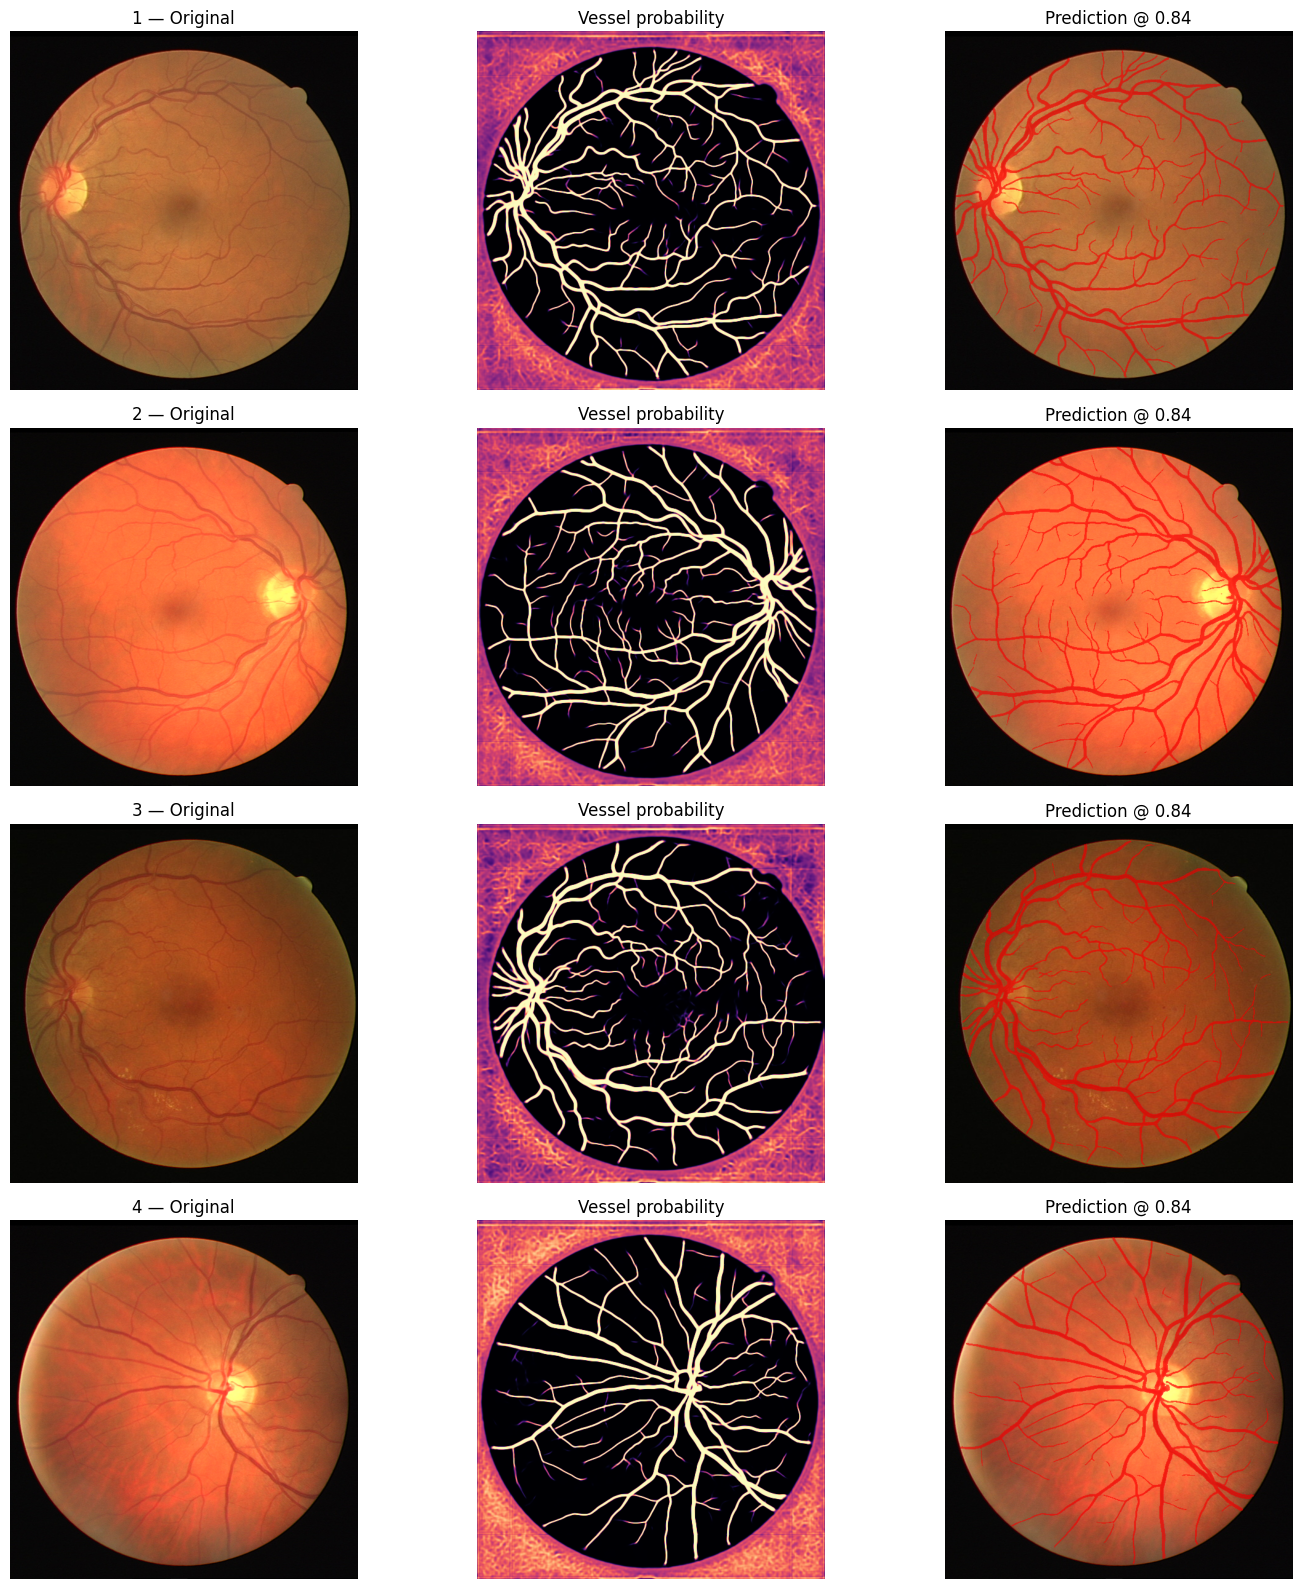

In [19]:
# ============================================================
# 19. Visualize final native-resolution predictions
# ============================================================
def prediction_overlay(rgb, pred_mask, alpha=0.60):
    return overlay_vessels(rgb, pred_mask.astype(np.uint8), alpha=alpha)

n_show = min(4, len(test_records))
n_cols = 4 if TEST_HAS_GT else 3
fig, axes = plt.subplots(n_show, n_cols, figsize=(5*n_cols, 4*n_show))
if n_show == 1:
    axes = np.expand_dims(axes, 0)

for row, r in enumerate(test_records[:n_show]):
    rgb, vessel, fov = load_record_arrays(r)
    prob = predict_full_image(final_ema, rgb, tta=USE_TTA_FOR_TEST)
    pred = (prob >= OOF_THRESHOLD).astype(np.uint8) * fov

    axes[row, 0].imshow(rgb)
    axes[row, 0].set_title(f"{r['id']} — Original")

    col = 1
    if TEST_HAS_GT:
        axes[row, col].imshow(overlay_vessels(rgb, vessel))
        axes[row, col].set_title("Ground-truth vessels")
        col += 1

    axes[row, col].imshow(prob, cmap="magma", vmin=0, vmax=1)
    axes[row, col].set_title("Vessel probability")
    col += 1

    axes[row, col].imshow(prediction_overlay(rgb, pred))
    axes[row, col].set_title(f"Prediction @ {OOF_THRESHOLD:.2f}")

    for c in range(n_cols):
        axes[row, c].axis("off")

plt.tight_layout()
plt.show()


In [20]:
# ============================================================
# 20. Save final deployment bundle
# ============================================================
final_bundle = {
    "architecture": "DenseNet121AttentionUNet_scSE_DeepSupervision",
    "task": "binary_retinal_vessel_segmentation",
    "model_state_dict": final_ema.state_dict(),
    "class_names": ["vessel"],
    "threshold": float(OOF_THRESHOLD),
    "threshold_source": "5-fold OOF predictions on official training set",
    "patch_size": PATCH_SIZE,
    "inference_stride": INFER_STRIDE,
    "inference": "native-resolution overlapping tiles",
    "tta": "identity+hflip+vflip+hvflip recommended for maximum-quality inference",
    "normalization": {
        "mean": IMAGENET_MEAN.tolist(),
        "std": IMAGENET_STD.tolist(),
    },
    "config": CONFIG,
    "final_refit_epochs": int(FINAL_EPOCHS),
    "cv_best_epochs": [int(x) for x in cv_summary["best_epoch"].tolist()],
    "oof_metrics": oof_final_metrics,
    "official_test_metrics_single_model": single_test_metrics,
    "test_vessel_ground_truth_available": bool(TEST_HAS_GT),
}

torch.save(final_bundle, FINAL_BUNDLE)

print("Saved files:")
for p in [
    FINAL_SINGLE_CKPT,
    FINAL_BUNDLE,
    OOF_THRESHOLD_JSON,
    CV_SUMMARY_CSV,
    FINAL_HISTORY_CSV,
    TEST_METRICS_CSV,
]:
    if p.exists():
        print(f"  {p}  ({p.stat().st_size / (1024**2):.2f} MB)")

print("\nFold checkpoints:")
for p in sorted(FOLD_DIR.glob("*.pth")):
    print(f"  {p}  ({p.stat().st_size / (1024**2):.2f} MB)")

print("\nMAIN SINGLE-MODEL BUNDLE FOR YOUR APP:")
print(FINAL_BUNDLE)

print("\nFor maximum-quality ensemble inference, retain all five fold checkpoints as well.")


Saved files:
  /kaggle/working/vessel_densenet121_attention_unet_final.pth  (87.06 MB)
  /kaggle/working/vessel_densenet121_attention_unet_final_bundle.pth  (87.06 MB)
  /kaggle/working/vessel_oof_threshold.json  (0.00 MB)
  /kaggle/working/vessel_cv_summary.csv  (0.00 MB)
  /kaggle/working/vessel_final_training_history.csv  (0.00 MB)

Fold checkpoints:
  /kaggle/working/vessel_cv_folds/vessel_fold_1_best.pth  (87.04 MB)
  /kaggle/working/vessel_cv_folds/vessel_fold_2_best.pth  (87.04 MB)
  /kaggle/working/vessel_cv_folds/vessel_fold_3_best.pth  (87.04 MB)
  /kaggle/working/vessel_cv_folds/vessel_fold_4_best.pth  (87.04 MB)
  /kaggle/working/vessel_cv_folds/vessel_fold_5_best.pth  (87.04 MB)

MAIN SINGLE-MODEL BUNDLE FOR YOUR APP:
/kaggle/working/vessel_densenet121_attention_unet_final_bundle.pth

For maximum-quality ensemble inference, retain all five fold checkpoints as well.


## Final model output

The deployment model produces one probability map:

```text
Fundus image
    ↓
DenseNet121 Attention U-Net
    ↓
Retinal vessel probability map
    ↓
OOF-calibrated threshold
    ↓
Binary retinal vessel mask
```

### Files to retain

- `vessel_densenet121_attention_unet_final_bundle.pth` — **main single-model application bundle**
- `vessel_densenet121_attention_unet_final.pth` — final checkpoint
- `vessel_oof_threshold.json` — cross-validated operating threshold
- `vessel_cv_summary.csv` — fold-level validation results
- `vessel_test_metrics.csv` — official test-set results for the single refit model
- `vessel_cv_folds/vessel_fold_1_best.pth` ... `fold_5_best.pth` — optional maximum-accuracy ensemble

### Deployment recommendation

For a practical application, use the **single final bundle**.

For offline maximum-quality inference, average probabilities from all five fold models and apply the same OOF-derived vessel threshold.
